# Day 13 — Intro to ML & scikit-learn (Regression)
Objective: Understand the ML workflow and train a first model.
Dataset: California Housing (predicting median house value)

## 1. Load Data: Features & Labels

Supervised learning uses labeled data: features (X) are the inputs,
the label (y) is the value we're trying to predict. This is a
regression problem since the target is continuous (a price), not a category.

In [2]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# Drop rows with missing values (small number, in total_bedrooms only)
df = df.dropna()

# One-hot encode the categorical column so all features are numeric
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## 2. Train/Test Split

Splitting data prevents the model from being evaluated on data it already
saw during training, which would give an unrealistically optimistic score.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16346
Testing samples: 4087


## 3. Feature Scaling

Features like income and room count are on very different scales.
Scaling puts them on comparable footing, which matters for models
sensitive to feature magnitude (and helps polynomial regression later).

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression:")
print(f"MAE: {mae_linear:.3f}")
print(f"MSE: {mse_linear:.3f}")
print(f"R²: {r2_linear:.3f}")

Linear Regression:
MAE: 50413.433
MSE: 4802173538.604
R²: 0.649


## 5. Polynomial Regression

Polynomial features let the model capture non-linear relationships.
Using degree=2 here — higher degrees risk overfitting on this dataset.

In [6]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression (degree=2):")
print(f"MAE: {mae_poly:.3f}")
print(f"MSE: {mse_poly:.3f}")
print(f"R²: {r2_poly:.3f}")

Polynomial Regression (degree=2):
MAE: 45069.732
MSE: 3978348042.380
R²: 0.709


## 6. Checking for Overfitting

Comparing training score vs test score. A model that scores much higher
on training data than test data is overfitting — it memorized noise
instead of learning the underlying pattern.

In [7]:
train_r2_linear = linear_model.score(X_train_scaled, y_train)
test_r2_linear = linear_model.score(X_test_scaled, y_test)

train_r2_poly = poly_model.score(X_train_poly, y_train)
test_r2_poly = poly_model.score(X_test_poly, y_test)

print("Linear    - Train R²:", round(train_r2_linear, 3), "| Test R²:", round(test_r2_linear, 3))
print("Polynomial- Train R²:", round(train_r2_poly, 3), "| Test R²:", round(test_r2_poly, 3))

Linear    - Train R²: 0.646 | Test R²: 0.649
Polynomial- Train R²: 0.714 | Test R²: 0.709


## 7. Comparing Predictions vs Actual Values

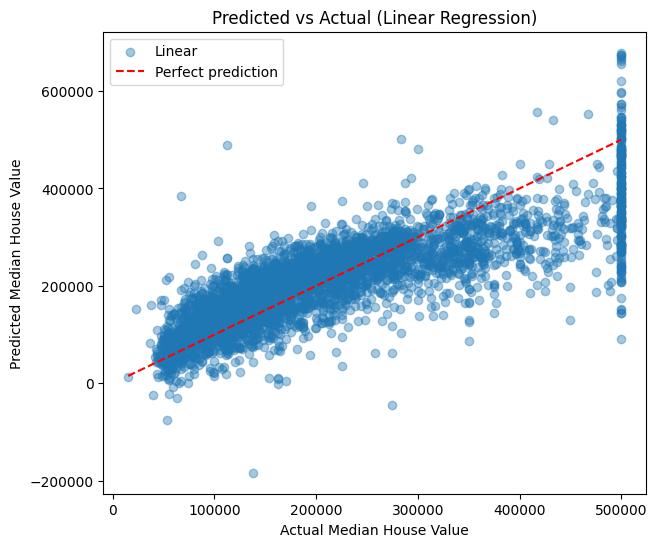

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.4, label="Linear")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect prediction")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Predicted vs Actual (Linear Regression)")
plt.legend()
plt.show()

## 8. Results Summary

| Model | MAE | MSE | R² (test) | R² (train) |
|---|---|---|---|---|

In [9]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression (deg=2)"],
    "MAE": [mae_linear, mae_poly],
    "MSE": [mse_linear, mse_poly],
    "R2_test": [test_r2_linear, test_r2_poly],
    "R2_train": [train_r2_linear, train_r2_poly],
})
results

,Model,MAE,MSE,R2_test,R2_train
0,Linear Regression,50413.433308,4.802174e+09,0.648840,0.645648
1,Polynomial Regression (deg=2),45069.732124,3.978348e+09,0.709083,0.714419
